# Notebook 01: **normalización, stopwords, stemming y lematización**

**Curso:** Procesamiento de Lenguaje Natural — Especialización en Inteligencia Artificial, Universidad de Cundinamarca
**Docente:** Paul Alexander Díaz Montaña
**Autor:** Yohan Nicolás Gómez Castañeda
**Base:** laboratorio de clase *Course 3 – Week 1* (Moroney, `dlaicourse`): `Tokenizer` de Keras y lista de stopwords del ejercicio de noticias de la BBC.

---

## Objetivo

Aplicar a un corpus periodístico real en español las cuatro operaciones que preparan el texto para cualquier tarea
posterior, y **medir el efecto de cada decisión** en lugar de darla por supuesta: cuánto vocabulario elimina, qué
información destruye y qué errores introduce.

| Sección | Tema | Pregunta que responde |
|---|---|---|
| 1 | Corpus | ¿Con qué texto se trabaja y cómo se distribuye su vocabulario? |
| 2 | **Normalización de texto** | ¿Qué hace el `Tokenizer` de clase con el español? ¿Qué ganan y qué cuestan las minúsculas y las tildes? |
| 3 | **Stopwords** | ¿Qué eliminan realmente las listas estándar? ¿Sirve la lista en inglés del laboratorio de clase? |
| 4 | **Stemming** | ¿Cuánto reduce el vocabulario el algoritmo Snowball y qué palabras mezcla por error? |
| 5 | **Lematización** | ¿Qué tan preciso es spaCy y cuánto depende del contexto? |
| 6 | Stemming frente a lematización | ¿Cuál conviene y para qué? |
| 7 | Exportación | Corpus preprocesado para los notebooks 02 y 03 |

El laboratorio anterior (*Transforma texto en embeddings*, [`lab-embeddings`](https://github.com/Nicolas2322/lab-embeddings))
señaló como limitación el uso de un corpus sintético generado por plantillas. Este laboratorio responde a esa
limitación trabajando con noticias reales.

## 0. Configuración del entorno

In [1]:
# Funciona igual en Google Colab y en local. En Colab clona el repositorio para disponer del paquete `pln_lab`
# y descarga el modelo de spaCy si hace falta.
import importlib.util, subprocess, sys
from pathlib import Path

REPO = "https://github.com/Nicolas2322/lab-procesamiento-texto.git"
EN_COLAB = "google.colab" in sys.modules

def raiz_del_repositorio() -> Path:
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "pln_lab").exists():
            return candidata
    if EN_COLAB:
        destino = Path("/content/lab-procesamiento-texto")
        if not destino.exists():
            subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
        return destino
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del repositorio.")

RAIZ = raiz_del_repositorio()
sys.path.insert(0, str(RAIZ / "src"))

if importlib.util.find_spec("es_core_news_md") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"], check=True)

print("Raíz del repositorio:", RAIZ, "| Colab:", EN_COLAB)

Raíz del repositorio: /home/claude/lab-procesamiento-texto | Colab: False


In [2]:
import json, random, re, time
import unicodedata
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nltk, spacy

from pln_lab.corpus import cargar_documentos_efe, documentos_a_dataframe
from pln_lab.preprocesamiento import (
    NEGACIONES, Normalizador, Stemmer, cargar_spacy, colisiones, es_palabra, lematizar_textos,
    normalizar_unicode, quitar_cabecera_agencia, quitar_stopwords, quitar_tildes, resumen_vocabulario,
    stopwords_nltk, stopwords_spacy, tokenizar, tokenizar_espacios,
)
from pln_lab.evaluacion import evaluar_lemas

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DIR_FIG = RAIZ / "notebooks" / "figuras"; DIR_RES = RAIZ / "notebooks" / "resultados"
for d in (DIR_FIG, DIR_RES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
AZUL, ROJO, VERDE, GRIS, NARANJA = "#2563eb", "#dc2626", "#16a34a", "#6b7280", "#d97706"
pd.set_option("display.max_colwidth", 90)

METRICAS = {}

def guardar_figura(nombre):
    plt.savefig(DIR_FIG / f"{nombre}.png"); plt.show()

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

print("spaCy", spacy.__version__, "| NLTK", nltk.__version__, "| pandas", pd.__version__)

spaCy 3.8.16 | NLTK 3.10.3 | pandas 3.0.2


## 1. Corpus de trabajo

Se usa la parte en español de **CoNLL-2002** (Tjong Kim Sang, 2002): noticias de la agencia **EFE** publicadas en
mayo de 2000, distribuidas con NLTK. Se eligió por tres razones:

1. **Es texto real**, con la ortografía, las abreviaturas y el ruido propios de la prensa (a diferencia del corpus
   sintético del laboratorio anterior).
2. **Trae anotaciones de referencia hechas por humanos**: categoría gramatical (etiquetas EAGLES) y entidades
   nombradas (formato IOB). En este notebook se usan para auditar qué destruye cada paso de preprocesamiento; en el
   notebook 03 servirán para evaluar el etiquetado gramatical y el reconocimiento de entidades.
3. **Se descarga con una línea** (`nltk.download("conll2002")`), lo que hace el laboratorio reproducible.

El corpus viene tokenizado oración por oración. La función `cargar_documentos_efe` reconstruye cada noticia (todas
empiezan con la cabecera *«Ciudad, fecha (EFE)»*) y recupera un texto corrido para que el preprocesamiento parta de
texto crudo, como ocurriría en una aplicación real.

In [3]:
documentos = cargar_documentos_efe()
corpus = documentos_a_dataframe(documentos)

resumen = pd.Series({
    "Documentos (noticias)": len(corpus),
    "Oraciones": corpus.n_oraciones.sum(),
    "Tokens (según CoNLL)": corpus.n_tokens.sum(),
    "Tokens por noticia (mediana)": int(corpus.n_tokens.median()),
    "Tokens por noticia (máximo)": corpus.n_tokens.max(),
}, name="valor")
METRICAS["corpus"] = {k: int(v) for k, v in resumen.items()}
display(resumen.to_frame())
print(corpus.texto[1][:500], "…")

,valor
Documentos (noticias),998
Oraciones,11755
Tokens (según CoNLL),369171
Tokens por noticia (mediana),313
Tokens por noticia (máximo),2344


Santander, 25 may (EFE). - Izquierda Unida de Santander presentó hoy su nuevo boletín trimestral "Ciudad", una publicación de la que se distribuirán 10.000 ejemplares preferentemente en los barrios del municipio donde la colación cuenta con mayor respaldo ciudadano. El portavoz del Consejo Político Municipal de IU en Santander, Ernesto Gómez de la Hera, explicó hoy en conferencia de prensa que este boletín persigue, más que informar, abrir espacios de debate y servir como "semilla de movilizació …


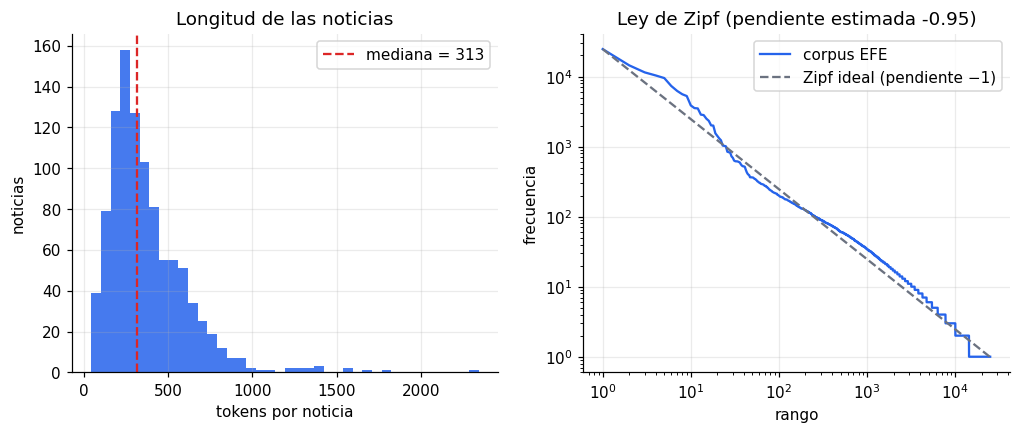

Pendiente log-log (primeros 5000 rangos): -0.949


In [4]:
# Distribución de longitudes y ley de Zipf (frecuencia frente a rango, escala logarítmica)
tokens_minuscula = [t.lower() for texto in corpus.texto for t in tokenizar(texto) if es_palabra(t)]
frecuencias = np.array(sorted(Counter(tokens_minuscula).values(), reverse=True))
rangos = np.arange(1, len(frecuencias) + 1)
pendiente = np.polyfit(np.log10(rangos[:5000]), np.log10(frecuencias[:5000]), 1)[0]
METRICAS["corpus"]["pendiente_zipf"] = round(float(pendiente), 3)

fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
ejes[0].hist(corpus.n_tokens, bins=40, color=AZUL, alpha=0.85)
ejes[0].axvline(corpus.n_tokens.median(), color=ROJO, ls="--", label=f"mediana = {int(corpus.n_tokens.median())}")
ejes[0].set(title="Longitud de las noticias", xlabel="tokens por noticia", ylabel="noticias"); ejes[0].legend()
ejes[1].loglog(rangos, frecuencias, color=AZUL, lw=1.5, label="corpus EFE")
ejes[1].loglog(rangos, frecuencias[0] / rangos, color=GRIS, ls="--", label="Zipf ideal (pendiente −1)")
ejes[1].set(title=f"Ley de Zipf (pendiente estimada {pendiente:.2f})", xlabel="rango", ylabel="frecuencia")
ejes[1].legend()
guardar_figura("fig01_01_corpus_zipf")
print(f"Pendiente log-log (primeros 5000 rangos): {pendiente:.3f}")

**Análisis.** El corpus reúne 998 noticias
con una longitud muy desigual: la mayoría son notas breves, pero hay crónicas y resúmenes de agenda que multiplican
varias veces la mediana. La curva rango-frecuencia sigue de cerca la ley de Zipf (pendiente estimada
-0,95, frente al −1 teórico): unas pocas
palabras concentran una fracción enorme de las ocurrencias y la mayor parte del vocabulario aparece una sola vez.
Esa asimetría explica las dos grandes líneas de este notebook: las **stopwords** atacan la cabeza de la
distribución (pocas palabras, muchísimos tokens) y el **stemming** y la **lematización** atacan la cola (muchas formas
raras que son variantes de la misma palabra).

## 2. Normalización de texto

Normalizar es transformar el texto para que **formas que deberían contar como la misma unidad se escriban igual**.
No existe una normalización correcta en abstracto: cada paso elimina variación, y parte de esa variación es ruido y
parte es información. La única forma de decidir es medir ambas cosas en el corpus concreto.

### 2.1 Lo que hace el `Tokenizer` del laboratorio de clase con el español

En el laboratorio de clase, el `Tokenizer` de Keras realiza toda la normalización de forma implícita: pasa a
minúsculas, elimina los signos incluidos en su parámetro `filters` y separa por espacios. Conviene examinar qué
significa eso para un texto en español.

In [5]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"          # silencia los mensajes informativos de TensorFlow
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer_clase = Tokenizer()
print("Filtros por defecto:", repr(tokenizer_clase.filters))
faltantes = [s for s in "¿¡«»—…" if s not in tokenizer_clase.filters]
print("Signos del español que NO están en los filtros:", faltantes)

ejemplo = ["¿Qué pasó en Bogotá? ¡Ganó Colombia!", "Qué partido: ganó Colombia."]
tokenizer_ejemplo = Tokenizer(); tokenizer_ejemplo.fit_on_texts(ejemplo)
print("word_index del ejemplo:", tokenizer_ejemplo.word_index)

tokenizer_clase.fit_on_texts(corpus.texto)
con_signo = {w: c for w, c in tokenizer_clase.word_counts.items() if re.search(r"[¿¡«»]", w)}
METRICAS["keras"] = {"vocabulario": len(tokenizer_clase.word_index), "tipos_con_signo_pegado": len(con_signo)}
print(f"Vocabulario Keras sobre el corpus: {len(tokenizer_clase.word_index):,}")
print(f"Tipos con ¿ ¡ « » pegados: {len(con_signo)} ->", sorted(con_signo, key=con_signo.get, reverse=True)[:10])

Filtros por defecto: '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
Signos del español que NO están en los filtros: ['¿', '¡', '«', '»', '—', '…']
word_index del ejemplo: {'colombia': 1, '¿qué': 2, 'pasó': 3, 'en': 4, 'bogotá': 5, '¡ganó': 6, 'qué': 7, 'partido': 8, 'ganó': 9}


Vocabulario Keras sobre el corpus: 25,987
Tipos con ¿ ¡ « » pegados: 15 -> ['¿dónde', '¿qué', '¿cómo', '¿por', '¡qué', '¿de', '¿está', '¿quién', '¿para', '¡oh']


**Análisis.** Los filtros por defecto de Keras se diseñaron para el inglés y **no incluyen los signos de apertura
del español** (¿, ¡, «, »). En el ejemplo, *«¿Qué»* y *«Qué»* terminan como dos entradas distintas del diccionario
aunque se trate de la misma palabra. En las noticias de EFE el problema es pequeño
(15 tipos afectados) porque la prensa
formula pocas preguntas directas, pero en reseñas, chats o redes sociales —donde las exclamaciones y preguntas son
constantes— el vocabulario se duplicaría artificialmente. La corrección es trivial (añadir los signos a `filters`),
pero solo se aplica si se sabe que el problema existe. A partir de aquí se usa una tokenización propia por
expresiones regulares (`pln_lab.preprocesamiento.tokenizar`) que trata cualquier signo como token independiente.

### 2.2 Normalización paso a paso

Cada etapa se aplica sobre la anterior y se mide el tamaño del vocabulario (número de *tipos*, es decir, de formas
distintas). La eliminación de tildes se evalúa por separado en la sección 2.4 porque, como se verá, no conviene
incluirla.

In [6]:
def etapas_de_normalizacion(textos):
    etapas = {}
    etapas["E0 · texto crudo, separado por espacios"] = [t for x in textos for t in tokenizar_espacios(x)]
    e1 = [t for x in textos for t in tokenizar(normalizar_unicode(x))]
    etapas["E1 · tokenización (signos separados)"] = e1
    e2 = [t.lower() for t in e1]
    etapas["E2 · minúsculas"] = e2
    e3 = [t for t in e2 if es_palabra(t) or t[0].isdigit()]
    etapas["E3 · sin signos de puntuación"] = e3
    e4 = ["<NUM>" if t[0].isdigit() else t for t in e3]
    etapas["E4 · números → <NUM>"] = e4
    e5 = [("<NUM>" if t[0].isdigit() else t.lower())
          for x in textos for t in tokenizar(quitar_cabecera_agencia(normalizar_unicode(x)))
          if es_palabra(t) or t[0].isdigit()]
    etapas["E5 · sin cabecera de agencia"] = e5
    return etapas

etapas = etapas_de_normalizacion(corpus.texto)
filas, tipos_previos, tipos_iniciales = [], None, None
for nombre, tokens in etapas.items():
    r = resumen_vocabulario(tokens)
    tipos_iniciales = tipos_iniciales or r["tipos"]
    filas.append({"etapa": nombre, "tokens": r["tokens"], "tipos": r["tipos"], "hapax": r["hapax"],
                  "reducción vs. etapa previa": "—" if tipos_previos is None else pct(1 - r["tipos"] / tipos_previos),
                  "reducción acumulada": pct(1 - r["tipos"] / tipos_iniciales)})
    tipos_previos = r["tipos"]
tabla_etapas = pd.DataFrame(filas)
METRICAS["normalizacion"] = {f["etapa"]: {"tokens": f["tokens"], "tipos": f["tipos"]} for f in filas}
display(tabla_etapas)

vocab_e4, vocab_e5 = Counter(etapas["E4 · números → <NUM>"]), Counter(etapas["E5 · sin cabecera de agencia"])
METRICAS["cabecera"] = {w: (vocab_e4[w], vocab_e5[w]) for w in ["efe", "may"]}
print("Frecuencia antes/después de quitar la cabecera:", METRICAS["cabecera"])

,etapa,tokens,tipos,hapax,reducción vs. etapa previa,reducción acumulada
0,"E0 · texto crudo, separado por espacios",323469,43553,23596,—,0.0 %
1,E1 · tokenización (signos separados),373810,30720,13899,29.5 %,29.5 %
2,E2 · minúsculas,373810,27624,12142,10.1 %,36.6 %
3,E3 · sin signos de puntuación,321918,27604,12140,0.1 %,36.6 %
4,E4 · números → <NUM>,321918,24956,10625,9.6 %,42.7 %
5,E5 · sin cabecera de agencia,316749,24840,10586,0.5 %,43.0 %


Frecuencia antes/después de quitar la cabecera: {'efe': (1418, 409), 'may': (1035, 71)}


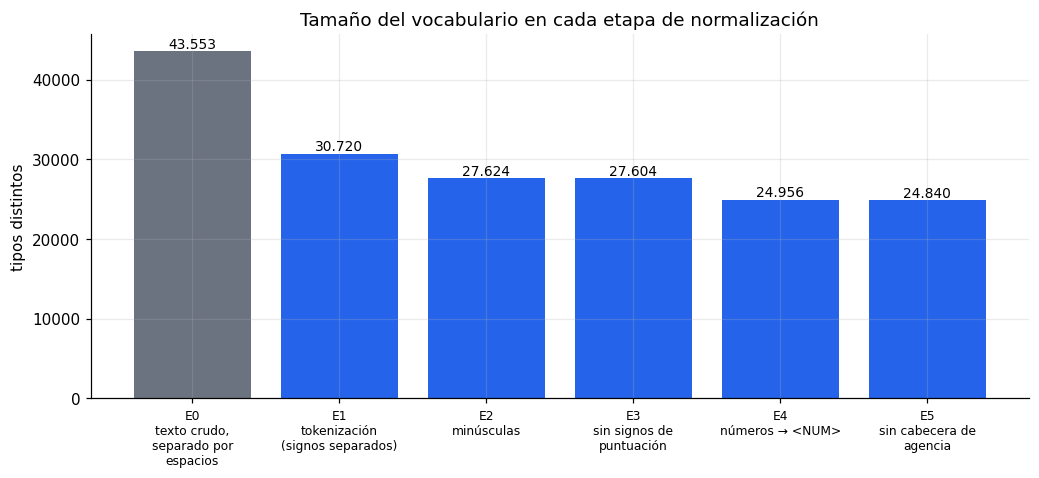

In [7]:
import textwrap
fig, ax = plt.subplots(figsize=(11, 4.3))
etiquetas = [e.split(" · ")[0] + "\n" + textwrap.fill(e.split(" · ")[1], 18) for e in tabla_etapas.etapa]
barras = ax.bar(etiquetas, tabla_etapas.tipos, color=[GRIS] + [AZUL] * (len(etiquetas) - 1))
for b, v in zip(barras, tabla_etapas.tipos):
    ax.text(b.get_x() + b.get_width() / 2, v + 400, f"{v:,}".replace(",", "."), ha="center", fontsize=9)
ax.set(title="Tamaño del vocabulario en cada etapa de normalización", ylabel="tipos distintos")
ax.tick_params(axis="x", labelsize=8)
guardar_figura("fig01_02_etapas_normalizacion")

**Análisis.** El paso que más vocabulario elimina no es ninguno de los que suelen asociarse con «normalizar», sino
la **tokenización**: al separar por espacios, *«Gobierno»*, *«Gobierno,»* y *«Gobierno.»* son tres tipos distintos, y
separar los signos reduce el vocabulario en 29,5 % (43.553 → 30.720 tipos). Las
**minúsculas** fusionan las palabras que aparecen al inicio de oración con sus apariciones internas; eliminar los
signos apenas cambia el número de tipos (los signos son pocos, aunque muy frecuentes en tokens), y reemplazar los
**números** por un marcador único elimina miles de tipos que casi nunca aportan significado temático (fechas, cifras,
resultados). La **cabecera de agencia** (*«Madrid, 25 may (EFE). -»*) es ruido específico del dominio: aparece en
cada noticia y situaba a *«efe»* y *«may»* entre las palabras más frecuentes del corpus. Quitarla apenas cambia el
número de tipos, pero reduce la frecuencia de *«efe»* de 1.418 a 409
y la de *«may»* de 1.035 a 71; las apariciones restantes son
menciones legítimas dentro del texto (*«la Agencia EFE»*, fechas en resúmenes de agenda). En conjunto, la
normalización reduce el vocabulario en 43,0 % sin haber tocado todavía la morfología.

### 2.3 El costo de las minúsculas: nombres propios que se funden con palabras comunes

Las minúsculas parecen inocuas, pero en español la mayúscula distingue con frecuencia una **entidad** de una
**palabra común**: *el Gobierno* (institución) frente a *el gobierno de la casa*, *Unión Europea* frente a *unión*,
*Paz* (apellido o ciudad) frente a *paz*. Las anotaciones de entidades de CoNLL-2002 permiten cuantificarlo.

In [8]:
etiqueta_ner = defaultdict(Counter)       # forma exacta -> {ENTIDAD/O: ocurrencias}
for doc in documentos:
    for oracion in doc.oraciones:
        for palabra, _, iob in oracion:
            if es_palabra(palabra):
                etiqueta_ner[palabra]["O" if iob == "O" else "ENTIDAD"] += 1

fusiones = []
for forma, miembros in colisiones(etiqueta_ner, str.lower).items():
    entidad = [m for m in miembros if m[0].isupper() and etiqueta_ner[m]["ENTIDAD"] >= 3
               and etiqueta_ner[m]["ENTIDAD"] / sum(etiqueta_ner[m].values()) >= 0.6]
    comun = [m for m in miembros if m.islower() and etiqueta_ner[m]["O"] >= 3]
    if entidad and comun:
        fusiones.append({"forma en minúscula": forma,
                         "como entidad": sum(etiqueta_ner[m]["ENTIDAD"] for m in entidad),
                         "como palabra común": sum(etiqueta_ner[m]["O"] for m in comun),
                         "variantes": ", ".join(sorted(miembros))})
fusiones = pd.DataFrame(fusiones).sort_values("como entidad", ascending=False)
tokens_entidad_total = sum(c["ENTIDAD"] for c in etiqueta_ner.values())
share = fusiones["como entidad"].sum() / tokens_entidad_total
METRICAS["minusculas_entidades"] = {"formas_fusionadas": len(fusiones), "proporcion_tokens_entidad": round(share, 4)}
print(f"{len(fusiones)} formas donde una entidad y una palabra común quedan fusionadas;"
      f" afectan al {pct(share)} de los tokens que forman parte de entidades.")
display(fusiones.head(15).reset_index(drop=True))

613 formas donde una entidad y una palabra común quedan fusionadas; afectan al 21.6 % de los tokens que forman parte de entidades.


,forma en minúscula,como entidad,como palabra común,variantes
0,gobierno,447,111,"GOBIERNO, Gobierno, gobierno"
1,real,186,23,"REAL, Real, real"
2,nacional,140,77,"NACIONAL, Nacional, nacional"
3,consejo,138,15,"CONSEJO, Consejo, consejo"
4,ayuntamiento,131,19,"Ayuntamiento, ayuntamiento"
5,junta,130,20,"JUNTA, Junta, junta"
6,comisión,124,63,"Comisión, comisión"
7,estado,118,94,"ESTADO, Estado, estado"
8,estados,110,18,"Estados, estados"
9,liga,106,20,"LIGA, Liga, liga"


**Análisis.** 613 formas mezclan una entidad con una palabra común al pasar a
minúsculas, y esas formas representan el 21,6 % de todos los tokens que forman
parte de entidades nombradas en el corpus. Los casos más frecuentes son instituciones cuyo nombre es un sustantivo
común (*Gobierno*, *Estado*, *Congreso*, *Unión*). La consecuencia práctica es de **orden en la cadena de
procesamiento**: el reconocimiento de entidades (notebook 03) y el etiquetado gramatical deben ejecutarse sobre el
texto original, y las minúsculas solo se aplican en la rama que alimenta representaciones de bolsa de palabras
(notebook 02).

### 2.4 ¿Quitar tildes? Fusiones que corrigen y fusiones que destruyen

Eliminar diacríticos es una práctica heredada del inglés y muy extendida. En español tiene dos efectos opuestos:
**corrige errores** (*«pais»* escrito sin tilde se une a *«país»*) y **borra distinciones gramaticales** (*el/él*,
*está/esta*, *más/mas*, *trabajo/trabajó*). La función `quitar_tildes` conserva la ñ; sin esa precaución, *año* y *ano*
también se fusionarían.

Para separar ambos efectos se usa la anotación gramatical de referencia: si las formas fusionadas tienen categorías
distintas (y cada una aparece al menos cinco veces) se cuenta como **distinción perdida**; si comparten categoría, como
**variante ortográfica**. Es una regla aproximada —las formas mal escritas a veces reciben etiquetas extrañas en la
anotación— pero separa bien los casos frecuentes.

In [9]:
categoria = defaultdict(Counter)   # palabra en minúscula -> {etiqueta gruesa: ocurrencias}
for doc in documentos:
    for oracion in doc.oraciones:
        for palabra, etiqueta, _ in oracion:
            gruesa = "NC" if etiqueta[:2] in ("NC", "NP") else etiqueta[:2]
            categoria[palabra.lower()][gruesa] += 1

vocab = vocab_e5
filas = []
for forma, miembros in colisiones(vocab, quitar_tildes).items():
    frecuentes = [m for m in miembros if vocab[m] >= 5]
    etiquetas = {categoria[m].most_common(1)[0][0] for m in frecuentes if categoria[m]}
    tipo = "distinción perdida" if len(frecuentes) > 1 and len(etiquetas) > 1 else "variante ortográfica"
    dominante, *absorbidas = sorted(miembros, key=vocab.get, reverse=True)
    filas.append({"forma sin tilde": forma, "tipo": tipo, "tokens": sum(vocab[m] for m in miembros),
                  "fusión": f"{', '.join(absorbidas)} → {dominante}", "tokens absorbidos": sum(vocab[m] for m in absorbidas),
                  "detalle": ", ".join(f"{m} ({vocab[m]}, {categoria[m].most_common(1)[0][0] if categoria[m] else '?'})"
                                       for m in sorted(miembros, key=vocab.get, reverse=True))})
tildes = pd.DataFrame(filas).sort_values("tokens", ascending=False).reset_index(drop=True)
resumen_tildes = tildes.groupby("tipo").agg(grupos=("forma sin tilde", "size"), tokens=("tokens", "sum"))
resumen_tildes["% de tokens del corpus"] = (resumen_tildes.tokens / sum(vocab.values())).map(pct)
METRICAS["tildes"] = {"tipos_antes": len(vocab), "tipos_despues": len(Counter(map(quitar_tildes, vocab.elements()))),
                      **{t: {"grupos": int(r.grupos), "tokens": int(r.tokens)} for t, r in resumen_tildes.iterrows()}}
display(resumen_tildes)
display(tildes[["forma sin tilde", "tipo", "tokens", "detalle"]].head(14))

,grupos,tokens,% de tokens del corpus
tipo,,,
distinción perdida,59,57704,18.2 %
variante ortográfica,462,13259,4.2 %


,forma sin tilde,tipo,tokens,detalle
0,de,distinción perdida,24593,"de (24583, SP), dé (10, VM)"
1,el,distinción perdida,11537,"el (11460, DA), él (77, PP)"
2,que,distinción perdida,10410,"que (10364, PR), qué (46, PT)"
3,se,distinción perdida,3512,"se (3506, P0), sé (6, VM)"
4,esta,distinción perdida,1064,"esta (691, DD), está (346, VM), ésta (27, PD)"
5,como,distinción perdida,1038,"como (1008, CS), cómo (30, PT)"
6,este,distinción perdida,869,"este (819, DD), éste (34, PD), esté (16, VM)"
7,mas,distinción perdida,869,"más (844, RG), mas (25, CC)"
8,segun,variante ortográfica,620,"según (618, SP), segun (2, AQ)"
9,o,variante ortográfica,400,"o (398, CC), ó (2, Fz)"


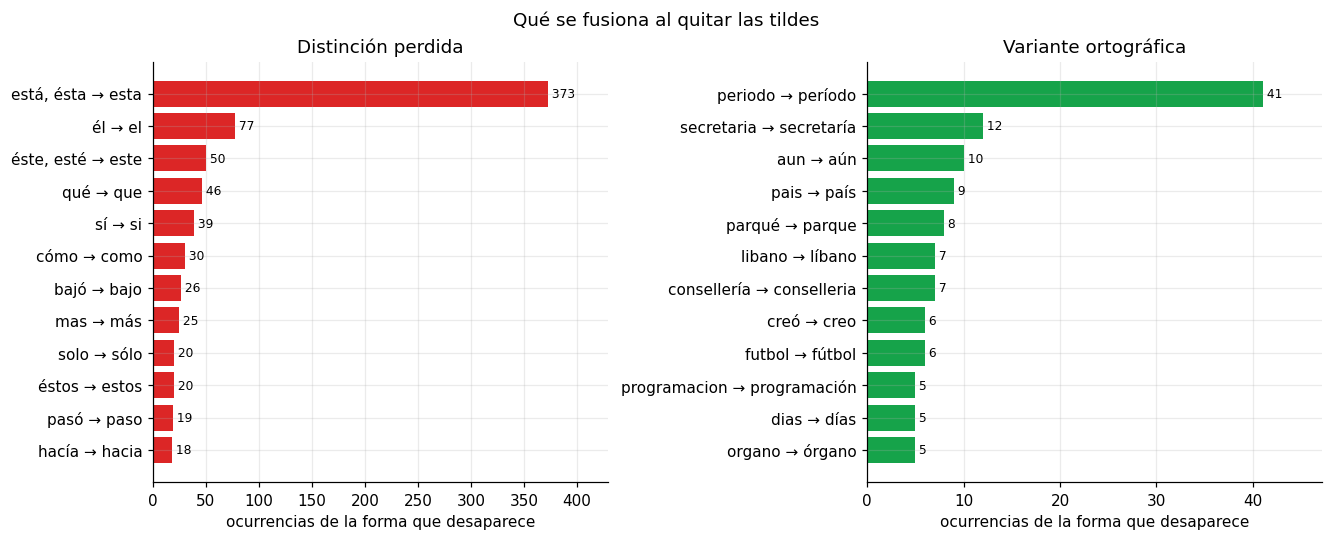

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
for eje, tipo, color in zip(ejes, ["distinción perdida", "variante ortográfica"], [ROJO, VERDE]):
    top = tildes[tildes.tipo == tipo].sort_values("tokens absorbidos", ascending=False).head(12)[::-1]
    eje.barh(top["fusión"], top["tokens absorbidos"], color=color)
    for y, v in enumerate(top["tokens absorbidos"]):
        eje.text(v, y, f" {v}", va="center", fontsize=8)
    eje.set(title=tipo.capitalize(), xlabel="ocurrencias de la forma que desaparece",
            xlim=(0, top["tokens absorbidos"].max() * 1.15))
fig.suptitle("Qué se fusiona al quitar las tildes", fontsize=12)
guardar_figura("fig01_03_colisiones_tildes")

**Análisis.** Quitar tildes reduce el vocabulario de 24.840 a 24.312
tipos, una ganancia modesta. La mayoría de los grupos (462) son variantes ortográficas —errores
tipográficos como *pais*, *futbol* o *comunicacion*— y ahí el paso ayuda. Pero los 59 grupos
que borran una distinción gramatical concentran 57.704 tokens, porque afectan justamente a las
palabras más frecuentes del idioma: el artículo *el* se funde con el pronombre *él*, el demostrativo *esta* con el verbo
*está*, la conjunción *si* con el adverbio afirmativo *sí*, el relativo *que* con el interrogativo *qué*.

La regla de clasificación, además, **subestima** las distinciones perdidas: solo detecta las que cambian la categoría
gramatical. Entre las «variantes ortográficas» aparecen fusiones que también borran significado sin cambiar de
categoría, como *creó/creo* (pasado frente a presente), *secretaria/secretaría* (persona frente a oficina) o
*parqué/parque*.

Para una bolsa de palabras temática la pérdida es tolerable, porque esas palabras se eliminarán igual como
stopwords. Para cualquier tarea que dependa de la estructura de la oración (etiquetado, análisis sintáctico,
traducción, preguntas y respuestas) es inaceptable. **Decisión:** la cadena `Normalizador` conserva las tildes por
defecto (`quitar_diacriticos=False`); los errores tipográficos se corrigen mejor con un corrector ortográfico que con
una transformación que también destruye información.

### 2.5 Texto ruidoso: el caso de las redes sociales

La prensa es un texto limpio. Para mostrar las operaciones de normalización que exige el texto informal (URLs,
menciones, emojis, alargamientos expresivos) se construyeron seis mensajes de ejemplo al estilo de redes sociales. No
forman parte del corpus: ilustran el comportamiento de cada regla.

In [11]:
mensajes = [
    "@MinSalud ¡¡¡Graciaaaas!!! por la info 👏👏 https://t.co/abc123 #VacunaciónYa",
    "Nooo puedo creerlo 😱😱 el partido terminó 3-2, ¿quién lo viooo?",
    "Escríbanme a soporte.cliente@empresa.com.co si tienen problemas con el pedido #1234",
    "Q buen servicio, lo recomiendo 100% jajajaja",
    "Hoy 16/09/2026 se cayó la app OTRA VEZ... @Banco resuelvan ya",
    "Café co\u0301mo siempre en Bogotá ☕",   # tilde escrita como carácter combinante (Unicode descompuesto)
]
normalizador = Normalizador(quitar_cabecera=False)
display(pd.DataFrame({"mensaje original": mensajes,
                      "tokens normalizados": [" ".join(normalizador(m)) for m in mensajes]}))

compuesta, descompuesta = "cómo", "co\u0301mo"
print(f"'{compuesta}' == '{descompuesta}' antes de NFC: {compuesta == descompuesta} "
      f"(longitudes {len(compuesta)} y {len(descompuesta)}); después de NFC: "
      f"{normalizar_unicode(compuesta) == normalizar_unicode(descompuesta)}")
descompuestos = sum(unicodedata.normalize("NFC", x) != x for x in corpus.texto)
print("Noticias del corpus con caracteres descompuestos:", descompuestos)

,mensaje original,tokens normalizados
0,@MinSalud ¡¡¡Graciaaaas!!! por la info 👏👏 https://t.co/abc123 #VacunaciónYa,<USUARIO> gracias por la info <EMOJI> <URL> vacunación ya
1,"Nooo puedo creerlo 😱😱 el partido terminó 3-2, ¿quién lo viooo?",no puedo creerlo <EMOJI> el partido terminó <NUM> <NUM> quién lo vio
2,Escríbanme a soporte.cliente@empresa.com.co si tienen problemas con el pedido #1234,escríbanme a <EMAIL> si tienen problemas con el pedido <NUM>
3,"Q buen servicio, lo recomiendo 100% jajajaja",q buen servicio lo recomiendo <NUM> jajajaja
4,Hoy 16/09/2026 se cayó la app OTRA VEZ... @Banco resuelvan ya,hoy <FECHA> se cayó la app otra vez <USUARIO> resuelvan ya
5,Café cómo siempre en Bogotá ☕,café cómo siempre en bogotá <EMOJI>


'cómo' == 'cómo' antes de NFC: False (longitudes 4 y 5); después de NFC: True
Noticias del corpus con caracteres descompuestos: 0


**Análisis.** Las reglas resuelven los fenómenos más comunes: menciones, URLs, correos, fechas y emojis se sustituyen
por marcadores (conservan la señal de que *había* un enlace o un emoji sin multiplicar el vocabulario), los hashtags
conservan la palabra y se separan cuando vienen en CamelCase (*#VacunaciónYa → vacunación ya*), y los alargamientos
expresivos se reducen respetando las consonantes que el español duplica legítimamente (*acción*, *llamar*, *carro*).
La regla tiene un costo conocido: como reduce las vocales repetidas a una sola, un improbable *«leeeer»* quedaría como
*«ler»*. La normalización Unicode (NFC) es invisible pero necesaria: una palabra con la
tilde codificada como carácter combinante es, para Python, una cadena distinta de la misma palabra escrita con el
carácter precompuesto. El corpus de EFE no contiene esos casos, pero es habitual en texto copiado de PDF o de
dispositivos móviles.

También quedan claros los límites de las reglas: *«Q»* (abreviatura de *qué*), *«jajajaja»* o el *«OTRA VEZ»* en
mayúsculas enfáticas requieren diccionarios de normalización léxica o modelos entrenados con texto informal.

## 3. Stopwords

Las *stopwords* (palabras vacías) son palabras muy frecuentes y de función gramatical —artículos, preposiciones,
conjunciones, pronombres, auxiliares— que se eliminan porque aportan poco a la identificación del tema. Eliminarlas
reduce drásticamente el número de tokens, pero la definición de «palabra vacía» depende de la tarea, y las listas
estándar son decisiones de otros tomadas para otros fines.

Se comparan tres listas: la del **laboratorio de clase** (en inglés, del ejercicio de noticias de la BBC), la de
**NLTK** para español y la de **spaCy** para español.

In [12]:
import urllib.request
URL_LAB = ("https://raw.githubusercontent.com/lmoroney/dlaicourse/master/TensorFlow%20In%20Practice/"
           "Course%203%20-%20NLP/Course%203%20-%20Week%201%20-%20Exercise-answer.ipynb")
fuente_lab = urllib.request.urlopen(URL_LAB).read().decode("utf-8")
celda_stop = next(c for c in json.loads(fuente_lab)["cells"] if "stopwords = [" in "".join(c["source"]))
stop_clase = set(re.findall(r'"([a-z\']+)"', "".join(celda_stop["source"]).split("stopwords = [")[1].split("]")[0]))

stop_nltk, stop_spacy = stopwords_nltk(), stopwords_spacy()
stop_recomendada = stop_nltk - NEGACIONES          # decisión justificada al final de la sección
listas = {"Laboratorio de clase (inglés)": stop_clase, "NLTK (español)": stop_nltk,
          "spaCy (español)": stop_spacy, "NLTK sin negaciones": stop_recomendada}

tokens_norm = etapas["E5 · sin cabecera de agencia"]
vocab = Counter(tokens_norm); total = sum(vocab.values())
tabla_listas = pd.DataFrame([{
    "lista": nombre, "palabras en la lista": len(lista),
    "presentes en el corpus": sum(1 for w in lista if vocab[w]),
    "% de tokens eliminados": pct(sum(vocab[w] for w in lista) / total),
    "tipos restantes": sum(1 for w in vocab if w not in lista)} for nombre, lista in listas.items()])
METRICAS["stopwords"] = {r["lista"]: {"tokens_eliminados": r["% de tokens eliminados"]} for _, r in tabla_listas.iterrows()}
display(tabla_listas)
print("Intersección NLTK ∩ spaCy:", len(stop_nltk & stop_spacy), "| solo spaCy:", len(stop_spacy - stop_nltk))

coincidencias = {w: vocab[w] for w in stop_clase if vocab[w]}
print("\nPalabras de la lista en inglés que aparecen en el corpus:",
      dict(sorted(coincidencias.items(), key=lambda kv: -kv[1])))

,lista,palabras en la lista,presentes en el corpus,% de tokens eliminados,tipos restantes
0,Laboratorio de clase (inglés),153,24,2.0 %,24816
1,NLTK (español),313,207,45.7 %,24633
2,spaCy (español),521,453,52.0 %,24387
3,NLTK sin negaciones,309,203,45.0 %,24637


Intersección NLTK ∩ spaCy: 165 | solo spaCy: 356

Palabras de la lista en inglés que aparecen en el corpus: {'a': 6229, 'me': 101, 'he': 36, 'once': 29, 'i': 20, 'the': 16, 'do': 15, 'at': 9, 'and': 8, 'of': 5, 'in': 3, 'as': 3, 'on': 3, 'this': 2, 'for': 2, 'it': 1, 'only': 1, 'your': 1, 'am': 1, 'if': 1, 'you': 1, 'nor': 1, 'an': 1, 'my': 1}


**Análisis de la lista del laboratorio de clase.** Aplicada a texto en español, la lista en inglés elimina muy pocos
tokens, y casi todos por **coincidencias accidentales** entre idiomas: *a* es aquí una preposición española, *me* es
un pronombre español, *he* es una forma del verbo *haber* y, lo más llamativo, **once** —«una vez» en inglés— es el
número *once* en español, que desaparecería de frases como *«once personas murieron»*. Es un recordatorio de que una
lista de stopwords es un recurso **específico del idioma**: reutilizar el código del laboratorio sin cambiar la lista
produce un preprocesamiento que parece funcionar y no hace casi nada.

In [13]:
# ¿Qué categorías gramaticales se eliminan realmente? Auditoría con las etiquetas de referencia de CoNLL-2002.
NOMBRES_CAT = {"SP": "preposición", "DA": "artículo", "CC": "conjunción coord.", "CS": "conjunción subord.",
               "PR": "relativo", "P0": "pronombre 'se'", "PP": "pronombre personal", "DD": "demostrativo",
               "DP": "posesivo", "VA": "aux. haber", "VS": "verbo ser", "RG": "adverbio", "RN": "negación",
               "NC": "SUSTANTIVO", "AQ": "ADJETIVO", "VM": "VERBO LÉXICO"}
CONTENIDO = {"NC", "AQ", "VM"}

auditoria, ejemplos = {}, {}
for nombre in ["NLTK (español)", "spaCy (español)"]:
    lista, cuenta, contenido = listas[nombre], Counter(), Counter()
    for doc in documentos:
        for oracion in doc.oraciones:
            for palabra, etiqueta, _ in oracion:
                if palabra.lower() in lista:
                    cuenta[etiqueta[:2]] += 1
                    if etiqueta[:2] in CONTENIDO:
                        contenido[(palabra.lower(), NOMBRES_CAT[etiqueta[:2]])] += 1
    auditoria[nombre], ejemplos[nombre] = cuenta, contenido
    eliminados = sum(cuenta.values()); de_contenido = sum(cuenta[c] for c in CONTENIDO)
    METRICAS["stopwords"][nombre].update({"tokens_contenido": de_contenido,
                                          "proporcion_contenido": round(de_contenido / eliminados, 4)})
    print(f"{nombre}: {eliminados:,} tokens eliminados; {de_contenido:,} ({pct(de_contenido / eliminados)}) "
          "son sustantivos, adjetivos o verbos léxicos.")
    print("   más frecuentes:", ", ".join(f"{w} [{c}] ×{k}" for (w, c), k in contenido.most_common(12)))

NLTK (español): 144,627 tokens eliminados; 2,222 (1.5 %) son sustantivos, adjetivos o verbos léxicos.
   más frecuentes: está [VERBO LÉXICO] ×346, tiene [VERBO LÉXICO] ×293, estado [SUSTANTIVO] ×190, están [VERBO LÉXICO] ×160, estados [SUSTANTIVO] ×129, tienen [VERBO LÉXICO] ×124, tuvo [VERBO LÉXICO] ×86, sentido [SUSTANTIVO] ×76, tendrá [VERBO LÉXICO] ×69, estar [VERBO LÉXICO] ×64, estaba [VERBO LÉXICO] ×58, estará [VERBO LÉXICO] ×55


spaCy (español): 164,584 tokens eliminados; 11,504 (7.0 %) son sustantivos, adjetivos o verbos léxicos.
   más frecuentes: parte [SUSTANTIVO] ×363, dijo [VERBO LÉXICO] ×361, está [VERBO LÉXICO] ×346, tiene [VERBO LÉXICO] ×293, pasado [ADJETIVO] ×253, próximo [ADJETIVO] ×242, día [SUSTANTIVO] ×214, nueva [ADJETIVO] ×196, estado [SUSTANTIVO] ×190, explicó [VERBO LÉXICO] ×188, días [SUSTANTIVO] ×187, nuevo [ADJETIVO] ×178


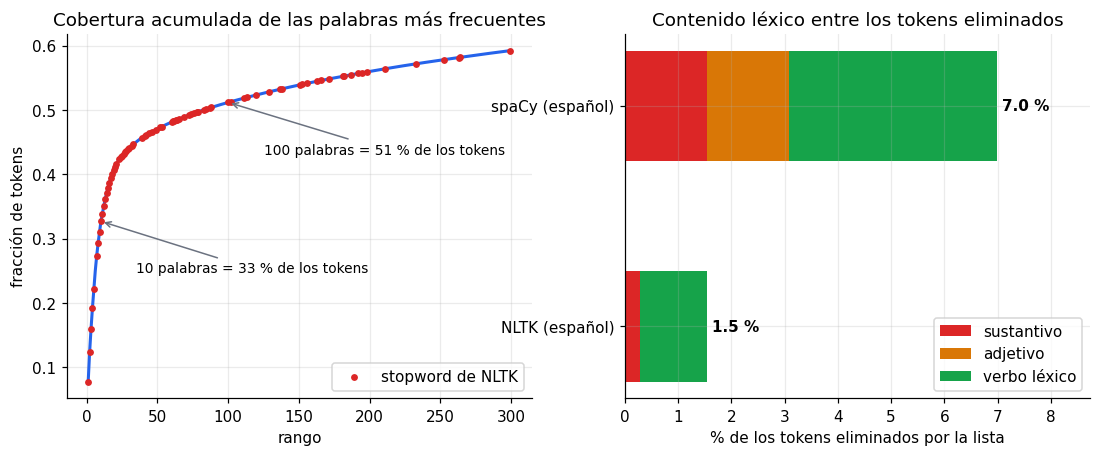

In [14]:
cobertura = np.cumsum([c for _, c in vocab.most_common()]) / total
rangos_stop = [i for i, (w, _) in enumerate(vocab.most_common(300)) if w in stop_nltk]

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.3))
ejes[0].plot(np.arange(1, 301), cobertura[:300], color=AZUL, lw=2)
ejes[0].scatter(np.array(rangos_stop) + 1, cobertura[rangos_stop], color=ROJO, s=12, zorder=3,
                label="stopword de NLTK")
for k in (10, 100):
    ejes[0].annotate(f"{k} palabras = {pct(cobertura[k - 1], 0)} de los tokens", (k, cobertura[k - 1]),
                     xytext=(k + 25, cobertura[k - 1] - 0.08), arrowprops=dict(arrowstyle="->", color=GRIS), fontsize=9)
ejes[0].set(title="Cobertura acumulada de las palabras más frecuentes", xlabel="rango", ylabel="fracción de tokens")
ejes[0].legend(loc="lower right")

grupos = {"sustantivo": "NC", "adjetivo": "AQ", "verbo léxico": "VM"}
nombres = ["NLTK (español)", "spaCy (español)"]; izquierda = np.zeros(2)
for (g, cod), color in zip(grupos.items(), [ROJO, NARANJA, VERDE]):
    valores = np.array([100 * auditoria[nm][cod] / sum(auditoria[nm].values()) for nm in nombres])
    ejes[1].barh(nombres, valores, left=izquierda, color=color, label=g, height=0.5); izquierda += valores
for y, total_c in enumerate(izquierda):
    ejes[1].text(total_c + 0.1, y, f"{total_c:.1f} %", va="center", fontsize=10, fontweight="bold")
ejes[1].set(title="Contenido léxico entre los tokens eliminados", xlabel="% de los tokens eliminados por la lista",
            xlim=(0, max(izquierda) * 1.25))
ejes[1].legend(loc="lower right")
guardar_figura("fig01_04_stopwords")

In [15]:
pares = ["El acuerdo no fue aprobado por el Congreso.", "El acuerdo fue aprobado por el Congreso.",
         "Nadie apoyó la reforma del Estado.", "Todos apoyaron la reforma del Estado."]
normalizador = Normalizador()
display(pd.DataFrame([{"oración": o, **{nm: " ".join(quitar_stopwords(normalizador(o), listas[nm]))
                                        for nm in ["NLTK (español)", "spaCy (español)", "NLTK sin negaciones"]}}
                      for o in pares]))
print("Negaciones incluidas en NLTK:", sorted(NEGACIONES & stop_nltk), "| en spaCy:", sorted(NEGACIONES & stop_spacy))

,oración,NLTK (español),spaCy (español),NLTK sin negaciones
0,El acuerdo no fue aprobado por el Congreso.,acuerdo aprobado congreso,aprobado congreso,acuerdo no aprobado congreso
1,El acuerdo fue aprobado por el Congreso.,acuerdo aprobado congreso,aprobado congreso,acuerdo aprobado congreso
2,Nadie apoyó la reforma del Estado.,nadie apoyó reforma,apoyó reforma,nadie apoyó reforma
3,Todos apoyaron la reforma del Estado.,apoyaron reforma,apoyaron reforma,apoyaron reforma


Negaciones incluidas en NLTK: ['nada', 'ni', 'no', 'sin'] | en spaCy: ['nada', 'nadie', 'ni', 'ninguna', 'ninguno', 'no', 'nunca', 'sin', 'tampoco']


**Análisis.** La curva de cobertura confirma lo anticipado por la ley de Zipf: diez palabras reúnen cerca de un
tercio de todos los tokens, y casi todos los puntos rojos (stopwords) están en la cabeza de la distribución. Por eso
la lista de NLTK, con apenas 313 palabras, elimina 45.7 % de los tokens.

La auditoría con la anotación de referencia muestra la diferencia entre ambas listas. En NLTK solo el
1,5 % de lo eliminado es contenido léxico, y casi todo corresponde a formas de *estar*
y *tener*, más un caso relevante para prensa: **estado/estados**, que la lista incluye como participio de *estar* pero
que en el corpus es sobre todo el sustantivo (*el Estado*, *Estados Unidos*). La lista de spaCy es mucho más agresiva:
el 7,0 % de lo que elimina son sustantivos, adjetivos o verbos léxicos, entre ellos
*acuerdo*, *parte*, *nuevo*, *próximo*, *dijo* o *señaló*, que en noticias son contenido informativo.

El experimento con pares de oraciones muestra el riesgo más serio: ambas listas incluyen **negaciones** (*no*, *sin*,
*nada*, *ni*; spaCy además *nunca*, *nadie*, *tampoco*), de modo que *«el acuerdo no fue aprobado»* y *«el acuerdo fue
aprobado»* producen exactamente la misma representación. Para clasificación temática da igual; para análisis de
sentimiento, detección de contradicciones o preguntas y respuestas invierte el significado.

**Decisión:** para el resto del laboratorio se usa la lista de NLTK **sin negaciones** (`NLTK sin negaciones`), y la
eliminación de stopwords se aplica solo en las tareas de bolsa de palabras; los modelos Transformer de los notebooks
04 y 05 reciben el texto completo, porque las palabras de función son precisamente lo que usan para interpretar la
oración.

## 4. Stemming

El *stemming* reduce cada palabra a una raíz (*stem*) eliminando sufijos mediante reglas, sin diccionario ni
contexto. Se usa el algoritmo **Snowball** para español (Porter, 2001), que aplica en orden: eliminación de pronombres
enclíticos (*-lo*, *-selo*), sufijos derivativos (*-ción*, *-mente*, *-idad*), sufijos verbales y, por último, vocales
finales. La raíz no tiene por qué ser una palabra real; basta con que las variantes de una misma palabra compartan la
misma raíz.

Se aplica sobre las palabras de contenido (tokens normalizados sin stopwords ni marcadores).

In [16]:
stemmer = Stemmer()
contenido = [t for t in tokens_norm if t not in stop_recomendada and not t.startswith("<")]
raices = stemmer.aplicar(contenido)
r_pal, r_raiz = resumen_vocabulario(contenido), resumen_vocabulario(raices)
METRICAS["stemming"] = {"tipos_palabras": r_pal["tipos"], "tipos_raices": r_raiz["tipos"],
                        "reduccion": round(1 - r_raiz["tipos"] / r_pal["tipos"], 4),
                        "hapax_palabras": r_pal["hapax"], "hapax_raices": r_raiz["hapax"]}
print(f"Tipos: {r_pal['tipos']:,} palabras → {r_raiz['tipos']:,} raíces ({pct(1 - r_raiz['tipos'] / r_pal['tipos'])} menos)")
print(f"Hapax (formas que aparecen una sola vez): {r_pal['hapax']:,} → {r_raiz['hapax']:,}")

vocab_contenido = Counter(contenido)
familias = colisiones(vocab_contenido, stemmer)
display(pd.DataFrame([{"raíz": r, "formas": len(m), "tokens": sum(vocab_contenido[w] for w in m),
                       "ejemplos": ", ".join(sorted(m, key=vocab_contenido.get, reverse=True)[:9])}
                      for r, m in sorted(familias.items(), key=lambda kv: -len(kv[1]))[:12]]))

Tipos: 24,636 palabras → 13,060 raíces (47.0 % menos)
Hapax (formas que aparecen una sola vez): 10,565 → 4,710


,raíz,formas,tokens,ejemplos
0,present,31,442,"presentado, presentación, presentó, presentada, presentar, presenta, presentará, prese..."
1,inform,27,520,"informó, información, informaron, informe, informado, informativo, informar, informaci..."
2,llev,25,213,"llevar, lleva, llevado, llevará, llevó, llevan, llevaba, llevaron, llevarse"
3,pas,25,565,"pasado, pasada, paso, pasar, pasó, pase, pasa, pasadas, pasando"
4,celebr,25,280,"celebrará, celebración, celebrada, celebra, celebrado, celebrar, celebrarán, celebró, ..."
5,pag,25,85,"pago, pagar, pagaron, pagados, pagó, paga, pagos, pagado, pagará"
6,cre,24,179,"crear, creo, cree, creado, creada, creemos, creará, creen, creó"
7,consider,23,240,"considera, consideró, considerar, consideran, consideración, considerado, consideradas..."
8,trat,23,167,"trata, tratar, tratan, tratado, trato, trataba, tratos, tratarán, tratará"
9,continu,23,152,"continúa, continuación, continuar, continua, continuo, continuidad, continuará, contin..."


In [17]:
# Casos que ilustran los dos tipos de error del stemming
casos = [
    ("sobre-agrupación", "crear (producir) / creer (opinar)", ["crear", "creó", "creer", "creo", "cree"]),
    ("sobre-agrupación", "parte / partido político / partir", ["parte", "partido", "partir"]),
    ("sobre-agrupación", "operación / ópera", ["operación", "ópera"]),
    ("sobre-agrupación", "autoridad / autor", ["autoridades", "autor", "autores"]),
    ("sobre-agrupación", "papa / papá", ["papa", "papá"]),
    ("sub-agrupación", "hacer", ["hacer", "hizo", "hecho", "haga", "hicieron"]),
    ("sub-agrupación", "decir", ["decir", "dijo", "dicho", "dice", "dijeron"]),
    ("sub-agrupación", "poder", ["poder", "puede", "pudo", "podrá"]),
    ("sub-agrupación", "año", ["año", "años"]),
    ("sub-agrupación", "contar / cuenta", ["contar", "cuenta", "cuento"]),
]
display(pd.DataFrame([{"error": e, "palabras": d, "raíces": ", ".join(f"{w}→{stemmer(w)}" for w in ws),
                       "raíces distintas": len({stemmer(w) for w in ws}),
                       "tokens en el corpus": sum(vocab_contenido[w] for w in ws)} for e, d, ws in casos]))

,error,palabras,raíces,raíces distintas,tokens en el corpus
0,sobre-agrupación,crear (producir) / creer (opinar),"crear→cre, creó→cre, creer→cre, creo→cre, cree→cre",1,103
1,sobre-agrupación,parte / partido político / partir,"parte→part, partido→part, partir→part",1,728
2,sobre-agrupación,operación / ópera,"operación→oper, ópera→oper",1,64
3,sobre-agrupación,autoridad / autor,"autoridades→autor, autor→autor, autores→autor",1,134
4,sobre-agrupación,papa / papá,"papa→pap, papá→pap",1,5
5,sub-agrupación,hacer,"hacer→hac, hizo→hiz, hecho→hech, haga→hag, hicieron→hic",5,379
6,sub-agrupación,decir,"decir→dec, dijo→dij, dicho→dich, dice→dic, dijeron→dijeron",5,478
7,sub-agrupación,poder,"poder→pod, puede→pued, pudo→pud, podrá→podr",4,309
8,sub-agrupación,año,"año→año, años→años",2,860
9,sub-agrupación,contar / cuenta,"contar→cont, cuenta→cuent, cuento→cuent",2,154


**Análisis.** El stemming casi **reduce a la mitad** el vocabulario de contenido (24.636 →
13.060 tipos, una reducción del 47,0 %) y divide por más de dos el número
de *hapax* (10.565 → 4.710), lo que en términos prácticos
significa matrices documento-término más pequeñas y menos dispersas. Las familias más grandes muestran su virtud: más de
veinte formas de *presentar* o de *celebrar* (tiempos verbales, participios y derivados) colapsan en una sola unidad.

Las mismas familias muestran sus dos defectos:

- **Sobre-agrupación**: palabras con significado distinto terminan con la misma raíz. *crear* y *creer* comparten *cre*
  (la familia de *cre* en el corpus mezcla *creó* con *creo*); *parte*, *partido* y *partir* se funden en *part*, de
  modo que una noticia sobre un partido político y otra sobre la partida de un tren parecen más cercanas de lo que son;
  *ópera* entra en la familia de *operación*, y *autoridades* se reduce a *autor*.
- **Sub-agrupación**: la misma palabra queda dispersa en varias raíces. Los verbos irregulares escapan a las reglas de
  sufijos (*hacer → hac, hiz, hech, hag, hic*) y hasta un caso regular como *año/años* queda separado, porque el
  algoritmo no elimina la *-s* final después de *ñ*. Es el error que más pesa en tokens, porque afecta a los verbos más
  frecuentes del idioma.

Ambos errores tienen la misma causa: el algoritmo no sabe qué palabra está procesando, solo qué letras tiene al final.

## 5. Lematización

La lematización reduce cada palabra a su **lema**, la forma que aparecería como entrada de diccionario (infinitivo
para los verbos, masculino singular para adjetivos y sustantivos). A diferencia del stemming, el resultado es siempre
—en principio— una palabra real, y el proceso puede usar el **contexto**: spaCy primero asigna la categoría gramatical
y los rasgos morfológicos de cada token con una red neuronal (`morphologizer`) y luego aplica reglas y tablas de
excepciones que dependen de esa categoría (`lemmatizer`). Se usa el modelo `es_core_news_md`.

### 5.1 Evaluación con el conjunto de referencia

El archivo `datos/lemas_referencia.csv` contiene 42 oraciones construidas para este laboratorio, cada una con una
palabra objetivo y su lema correcto, agrupadas por fenómeno: flexión nominal, flexión verbal regular e irregular,
pronombres enclíticos y **homógrafos** (la misma forma escrita con dos lemas posibles según el contexto, como *fue*
de *ser* o de *ir*). Cada palabra se lematiza de dos maneras: dentro de su oración y aislada.

In [18]:
nlp = cargar_spacy("es_core_news_md")
referencia = pd.read_csv(RAIZ / "datos" / "lemas_referencia.csv")
print(f"Conjunto de referencia: {len(referencia)} oraciones, {referencia.lema.nunique()} lemas distintos")
evaluacion = evaluar_lemas(nlp, referencia, stemmer=stemmer)

GRUPO = {"plural": "flexión nominal", "plural irregular (-ces)": "flexión nominal", "sustantivo invariable": "flexión nominal",
         "plural con tilde": "flexión nominal", "género": "flexión nominal", "género y número": "flexión nominal",
         "comparativo": "flexión nominal", "adjetivo": "flexión nominal", "sustantivo": "flexión nominal",
         "derivación": "derivación", "verbo regular": "verbo regular", "gerundio": "verbo regular",
         "participio": "verbo regular", "verbo irregular": "verbo irregular", "clíticos": "enclíticos"}
evaluacion["grupo"] = evaluacion.fenomeno.map(lambda x: "homografía" if x.startswith("homografía") else GRUPO[x])

por_grupo = evaluacion.groupby("grupo").agg(casos=("palabra", "size"), en_contexto=("acierto_contexto", "mean"),
                                            aislada=("acierto_aislado", "mean"))
acc_ctx, acc_ais = evaluacion.acierto_contexto.mean(), evaluacion.acierto_aislado.mean()
METRICAS["lematizacion"] = {"exactitud_contexto": round(acc_ctx, 4), "exactitud_aislada": round(acc_ais, 4),
                            "por_grupo": {g: {"casos": int(r.casos), "contexto": round(r.en_contexto, 3),
                                              "aislada": round(r.aislada, 3)} for g, r in por_grupo.iterrows()}}
print(f"Exactitud en contexto: {pct(acc_ctx)} | palabra aislada: {pct(acc_ais)}")
display(por_grupo.style.format({"en_contexto": "{:.0%}", "aislada": "{:.0%}"}))
errores = evaluacion[~evaluacion.acierto_contexto | ~evaluacion.acierto_aislado]
display(errores[["oracion", "palabra", "lema", "lema_contexto", "lema_aislado", "raiz"]].reset_index(drop=True))

Conjunto de referencia: 42 oraciones, 39 lemas distintos
Exactitud en contexto: 83.3 % | palabra aislada: 76.2 %


,casos,en_contexto,aislada
grupo,,,
derivación,4,100%,100%
enclíticos,3,0%,0%
flexión nominal,11,91%,100%
homografía,11,73%,55%
verbo irregular,6,100%,100%
verbo regular,7,100%,71%


,oracion,palabra,lema,lema_contexto,lema_aislado,raiz
0,Ella es una jugadora excelente.,jugadora,jugador,jugadora,jugador,jugador
1,Los resultados fueron publicados ayer.,publicados,publicar,publicar,publicado,public
2,La propuesta fue aprobada por mayoría.,aprobada,aprobar,aprobar,aprobado,aprob
3,Dámelo cuando termines.,dámelo,dar,dámelir,dámelir,damel
4,Tienes que decírselo pronto.,decírselo,decir,decir él él,decírselir,dec
5,Hay que cuidarlos bien.,cuidarlos,cuidar,cuidar él,cuidar él,cuid
6,Ella fue a Bogotá la semana pasada.,fue,ir,ser,ser,fue
7,Sirvieron un vino chileno en la cena.,vino,vino,vino,venir,vin
8,Yo como arroz todos los días.,como,comer,como,como,com
9,El trabajo terminó tarde.,trabajo,trabajo,trabajo,trabajar,trabaj


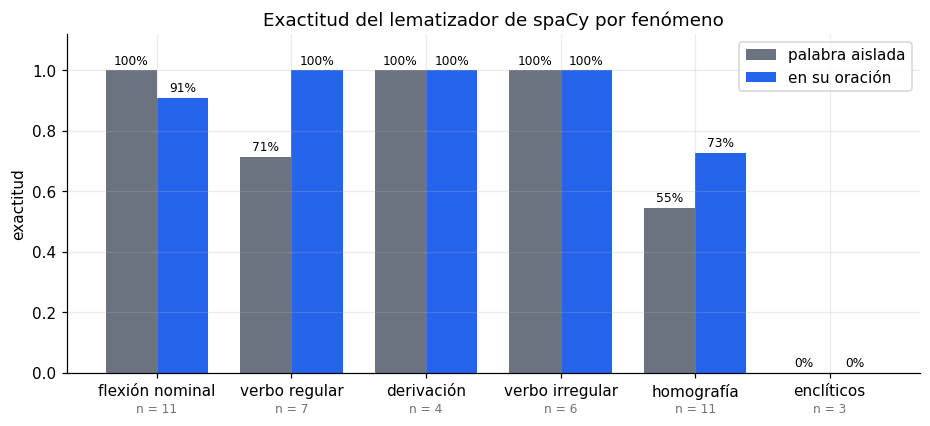

In [19]:
orden = ["flexión nominal", "verbo regular", "derivación", "verbo irregular", "homografía", "enclíticos"]
datos = por_grupo.reindex(orden)
x = np.arange(len(orden)); ancho = 0.38
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - ancho / 2, datos.aislada, ancho, color=GRIS, label="palabra aislada")
ax.bar(x + ancho / 2, datos.en_contexto, ancho, color=AZUL, label="en su oración")
for i, (a, c, k) in enumerate(zip(datos.aislada, datos.en_contexto, datos.casos)):
    ax.text(i - ancho / 2, a + 0.02, f"{a:.0%}", ha="center", fontsize=8)
    ax.text(i + ancho / 2, c + 0.02, f"{c:.0%}", ha="center", fontsize=8)
    ax.text(i, -0.13, f"n = {k}", ha="center", fontsize=8, color=GRIS)
ax.set_xticks(x, orden); ax.set_ylim(0, 1.12)
ax.set(title="Exactitud del lematizador de spaCy por fenómeno", ylabel="exactitud")
ax.legend(loc="upper right")
guardar_figura("fig01_05_lematizacion_por_fenomeno")

**Análisis.** spaCy acierta el 83,3 % de los lemas cuando ve la oración completa y el
76,2 % cuando recibe la palabra suelta. La diferencia no se reparte por igual:

- **Flexión nominal y derivación** se resuelven casi siempre bien. Donde el stemming fallaba (*autoridades → autor*,
  *peces → pec*), el lematizador devuelve *autoridad* y *pez*, y respeta la derivación: *organización* y *organizar*
  conservan lemas distintos, cosa que el stemming no puede hacer. El único fallo, *jugadora*, se lematiza como
  *jugadora* dentro de la oración porque el modelo la analiza como sustantivo femenino independiente; es un caso
  discutible, pues algunos diccionarios registran ambas formas por separado.
- **Verbos regulares**: aislados, los participios se interpretan como adjetivos (*publicados → publicado*,
  *aprobada → aprobado*); dentro de la oración (*«fueron publicados»*) el modelo reconoce el verbo y devuelve
  *publicar*. Es el efecto del contexto sobre la categoría gramatical, y de la categoría sobre el lema.
- **Verbos irregulares** (*hicieron → hacer*, *dijeron → decir*, *supimos → saber*): aciertos completos, con y sin
  contexto, gracias a las tablas de excepciones. Es exactamente el caso en el que el stemming dispersaba una palabra en varias raíces.
- **Homografía**: es donde el contexto cuenta. Aislada, *vino* siempre es *venir* y *trabajo* siempre es *trabajar*;
  en la oración, el modelo identifica el sustantivo. Pero no resuelve todo: *fue* se lematiza como *ser* también en
  *«fue a Bogotá»* (debería ser *ir*), *como* en *«yo como arroz»* no se reconoce como el verbo *comer*, y el árbol
  *haya* se confunde con el verbo *haber*.
- **Pronombres enclíticos**: es el punto débil del modelo. *cuidarlos* produce el lema compuesto *«cuidar él»* (el
  pronombre se lematiza aparte y se pega al verbo) y *dámelo* produce una forma inexistente (*«dámelir»*): el modelo
  trató la palabra entera como un infinitivo mal formado.

### 5.2 Lematización del corpus completo

In [20]:
nlp_rapido = cargar_spacy("es_core_news_md", deshabilitar=("ner", "parser"))
inicio = time.perf_counter()
analisis = lematizar_textos(nlp_rapido, [quitar_cabecera_agencia(t) for t in corpus.texto], batch_size=16)
duracion_lema = time.perf_counter() - inicio
n_tokens_spacy = sum(len(d) for d in analisis)
print(f"{n_tokens_spacy:,} tokens lematizados en {duracion_lema:.1f} s ({n_tokens_spacy / duracion_lema:,.0f} tokens/s)")

# Palabras de contenido sobre la tokenización de spaCy, para comparar stemming y lematización sobre los mismos tokens
triples = [(t.lower(), l.lower(), pos) for doc in analisis for t, l, pos in doc
           if es_palabra(t) and t.lower() not in stop_recomendada]
palabras_c = [t for t, _, _ in triples]; lemas_c = [l for _, l, _ in triples]; raices_c = stemmer.aplicar(palabras_c)

# Patrones de error detectables sin anotación: lemas que no existen como palabra en la tabla de vectores del modelo
existe = nlp.vocab.has_vector
lema_compuesto = Counter((t, l) for t, l, _ in triples if " " in l)
lema_inexistente = Counter((t, l) for t, l, _ in triples if " " not in l and existe(t) and not existe(l))
print(f"Tabla de formas del modelo: {nlp.vocab.vectors.n_keys:,} palabras")
print(f"Lemas compuestos por enclíticos (p. ej. 'hacer él'): {sum(lema_compuesto.values()):,} tokens →",
      [f"{t}→{l}" for (t, l), _ in lema_compuesto.most_common(6)])
print(f"Lemas inexistentes para palabras reales: {sum(lema_inexistente.values()):,} tokens →",
      [f"{t}→{l}" for (t, l), _ in lema_inexistente.most_common(12)])
METRICAS["lematizacion"].update({"tokens_por_segundo": round(n_tokens_spacy / duracion_lema),
                                 "tokens_lema_compuesto": sum(lema_compuesto.values()),
                                 "tokens_lema_inexistente": sum(lema_inexistente.values()),
                                 "tokens_contenido": len(triples)})

360,480 tokens lematizados en 15.9 s (22,683 tokens/s)


Tabla de formas del modelo: 500,000 palabras
Lemas compuestos por enclíticos (p. ej. 'hacer él'): 777 tokens → ['hacerlo→hacer él', 'presentarse→presentar él', 'enfrentarse→enfrentar él', 'hacerse→hacer él', 'situarse→situar él', 'convertirse→convertir él']
Lemas inexistentes para palabras reales: 565 tokens → ['reúne→reúnir', 'acudan→acudar', 'quisiéramos→quisiser', 'paracaídas→paracaída', 'fertilizantes→fertilizant', 'etíopes→etíop', 'regímenes→regímén', 'keniana→kenián', 'manifieste→manifiestir', 'producirían→produciriar', 'castrenses→castrens', 'reúnen→reúnir']


**Análisis.** Sobre el corpus completo aparecen, a escala, los mismos patrones del conjunto de referencia. Los
**enclíticos** generan 777 lemas compuestos (*hacerlo → «hacer él»*,
*presentarse → «presentar él»*) que fragmentan el vocabulario: *presentar* y *«presentar él»* cuentan como lemas
distintos. Aparte, 565 tokens reciben un lema que no existe (*reúne → «reúnir»*,
*acudan → «acudar»*, *quisiéramos → «quisiser»*): el modelo acierta que se trata de un verbo pero aplica la regla de
una conjugación equivocada. Son pocos frente a los 164.491 tokens de contenido, pero
indican que en producción conviene un paso de posprocesamiento (separar el enclítico antes de lematizar, o validar
el lema contra un diccionario).

## 6. Stemming frente a lematización sobre el corpus

Ambas técnicas se comparan sobre **los mismos tokens** (palabras de contenido según la tokenización de spaCy) con
cuatro criterios: cuánto reducen el vocabulario, si el resultado es una palabra legible, cuántas palabras distintas
mezclan y cuánto cuestan. Como aproximación a «es una palabra real» se usa la presencia de la forma en la tabla de
500 000 palabras del modelo de spaCy.

In [21]:
def mezcla(origen, destino, pesos):
    """Fracción de tokens cuya forma de destino agrupa más de un valor de origen."""
    grupos = defaultdict(set)
    for o, d in zip(origen, destino):
        grupos[d].add(o)
    multiples = {d for d, s in grupos.items() if len(s) > 1}
    return sum(1 for d in destino if d in multiples) / len(destino)

inicio = time.perf_counter()
_ = [Stemmer()._stemmer.stem(w) for w in palabras_c]      # sin caché, para medir el algoritmo
duracion_stem = time.perf_counter() - inicio

vocab_p, vocab_r, vocab_l = Counter(palabras_c), Counter(raices_c), Counter(lemas_c)
comparacion = pd.DataFrame({
    "tipos distintos": [len(vocab_p), len(vocab_r), len(vocab_l)],
    "reducción del vocabulario": ["—", pct(1 - len(vocab_r) / len(vocab_p)), pct(1 - len(vocab_l) / len(vocab_p))],
    "tipos que son palabras reales": [pct(sum(map(existe, vocab_p)) / len(vocab_p)),
                                      pct(sum(map(existe, vocab_r)) / len(vocab_r)),
                                      pct(sum(map(existe, vocab_l)) / len(vocab_l))],
    "tokens con forma real": [pct(sum(c for w, c in vocab_p.items() if existe(w)) / len(palabras_c)),
                              pct(sum(c for w, c in vocab_r.items() if existe(w)) / len(raices_c)),
                              pct(sum(c for w, c in vocab_l.items() if existe(w)) / len(lemas_c))],
    "tokens cuya forma mezcla lemas distintos": ["—", pct(mezcla(lemas_c, raices_c, None)), "—"],
    "tokens/segundo": ["—", f"{len(palabras_c) / duracion_stem:,.0f}", f"{n_tokens_spacy / duracion_lema:,.0f}"],
}, index=["palabras", "raíces (Snowball)", "lemas (spaCy)"])
METRICAS["comparacion"] = {
    "tipos": {"palabras": len(vocab_p), "raices": len(vocab_r), "lemas": len(vocab_l)},
    "tipos_reales": {"palabras": round(sum(map(existe, vocab_p)) / len(vocab_p), 4),
                     "raices": round(sum(map(existe, vocab_r)) / len(vocab_r), 4),
                     "lemas": round(sum(map(existe, vocab_l)) / len(vocab_l), 4)},
    "tokens_reales": {"palabras": round(sum(c for w, c in vocab_p.items() if existe(w)) / len(palabras_c), 4),
                      "raices": round(sum(c for w, c in vocab_r.items() if existe(w)) / len(raices_c), 4),
                      "lemas": round(sum(c for w, c in vocab_l.items() if existe(w)) / len(lemas_c), 4)},
    "mezcla_raices": round(mezcla(lemas_c, raices_c, None), 4),
    "velocidad": {"stemming": round(len(palabras_c) / duracion_stem), "lematizacion": round(n_tokens_spacy / duracion_lema)},
}
display(comparacion)

# Lemas frecuentes que el stemming dispersa en varias raíces
lema_a_raices = defaultdict(Counter)
for l, r in zip(lemas_c, raices_c):
    lema_a_raices[l][r] += 1
dispersos = sorted(((l, c) for l, c in lema_a_raices.items() if len(c) > 2), key=lambda x: -sum(x[1].values()))[:8]
display(pd.DataFrame([{"lema": l, "tokens": sum(c.values()), "raíces distintas": len(c),
                       "raíces": ", ".join(r for r, _ in c.most_common(8))} for l, c in dispersos]))

,tipos distintos,reducción del vocabulario,tipos que son palabras reales,tokens con forma real,tokens cuya forma mezcla lemas distintos,tokens/segundo
palabras,24552,—,85.5 %,95.5 %,—,—
raíces (Snowball),12992,47.1 %,34.5 %,68.7 %,65.8 %,"77,677"
lemas (spaCy),17670,28.0 %,76.0 %,94.8 %,—,"22,683"


,lema,tokens,raíces distintas,raíces
0,poder,757,6,"pued, pod, podr, pud, podran, poder"
1,hacer,607,7,"hac, hiz, hech, hag, har, hic, haran"
2,ser,571,3,"ser, sid, siend"
3,decir,485,7,"dij, dec, dic, dich, dijeron, dig, dir"
4,dar,277,17,"dar, dad, dio, da, dan, dieron, dab, dand"
5,mantener,232,6,"manten, mantien, mantuv, manteng, mantendr, mantendran"
6,ir,225,13,"va, van, ir, vam, iba, ira, vay, voy"
7,poner,162,6,"pon, pus, puest, pong, pondr, pondran"


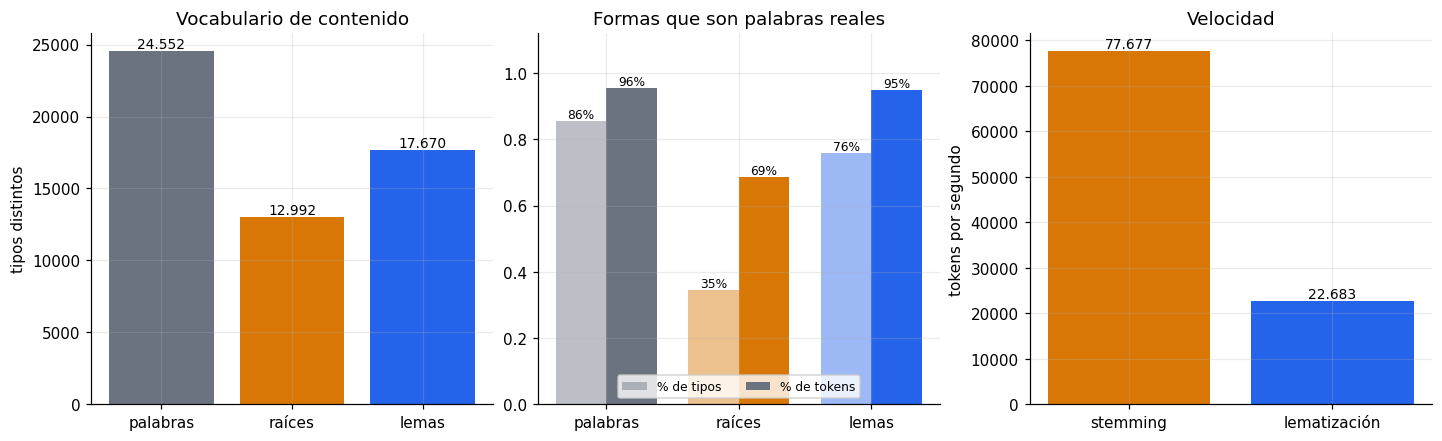

In [22]:
cm = METRICAS["comparacion"]
fig, ejes = plt.subplots(1, 3, figsize=(13, 3.9), layout="constrained")
etq, claves, col = ["palabras", "raíces", "lemas"], ["palabras", "raices", "lemas"], [GRIS, NARANJA, AZUL]
barras = ejes[0].bar(etq, [cm["tipos"][k] for k in claves], color=col)
ejes[0].bar_label(barras, labels=[f"{cm['tipos'][k]:,}".replace(",", ".") for k in claves], fontsize=9)
ejes[0].set(title="Vocabulario de contenido", ylabel="tipos distintos")
x = np.arange(3); ancho = 0.38
b1 = ejes[1].bar(x - ancho / 2, [cm["tipos_reales"][k] for k in claves], ancho, color=col, alpha=0.45, label="% de tipos")
b2 = ejes[1].bar(x + ancho / 2, [cm["tokens_reales"][k] for k in claves], ancho, color=col, label="% de tokens")
for b in (b1, b2):
    ejes[1].bar_label(b, labels=[f"{v.get_height():.0%}" for v in b], fontsize=8)
ejes[1].set_xticks(x, etq); ejes[1].set(title="Formas que son palabras reales", ylim=(0, 1.12))
ejes[1].legend(loc="lower center", fontsize=8, ncol=2)
b3 = ejes[2].bar(["stemming", "lematización"], [cm["velocidad"]["stemming"], cm["velocidad"]["lematizacion"]], color=col[1:])
ejes[2].bar_label(b3, labels=[f"{v:,}".replace(",", ".") for v in cm["velocidad"].values()], fontsize=9)
ejes[2].set(title="Velocidad", ylabel="tokens por segundo")
guardar_figura("fig01_06_stemming_vs_lematizacion")

In [23]:
# Una oración del corpus a través de toda la cadena
oracion = "Los ministros de Economía se reunieron hoy y no quisieron presentarlo, según explicaron los portavoces."
tokens_o = Normalizador()(oracion)
doc = nlp(oracion)
display(pd.DataFrame({
    "token": [t.text for t in doc if es_palabra(t.text)],
    "normalizado": [t.text.lower() for t in doc if es_palabra(t.text)],
    "¿stopword?": ["sí" if t.text.lower() in stop_recomendada else "" for t in doc if es_palabra(t.text)],
    "raíz": [stemmer(t.text.lower()) for t in doc if es_palabra(t.text)],
    "lema": [t.lemma_ for t in doc if es_palabra(t.text)],
    "categoría": [t.pos_ for t in doc if es_palabra(t.text)],
}).T)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
token,Los,ministros,de,Economía,se,reunieron,hoy,y,no,quisieron,presentarlo,según,explicaron,los,portavoces
normalizado,los,ministros,de,economía,se,reunieron,hoy,y,no,quisieron,presentarlo,según,explicaron,los,portavoces
¿stopword?,sí,,sí,,sí,,,sí,,,,,,sí,
raíz,los,ministr,de,econom,se,reun,hoy,y,no,quis,present,segun,explic,los,portavoc
lema,el,ministro,de,Economía,él,reunir,hoy,y,no,querer,presentar él,según,explicar,el,portavoz
categoría,DET,NOUN,ADP,PROPN,PRON,VERB,ADV,CCONJ,ADV,VERB,VERB,SCONJ,VERB,DET,NOUN


**Análisis.** La comparación sobre los mismos tokens resume el compromiso entre ambas técnicas:

| Criterio | Stemming (Snowball) | Lematización (spaCy) |
|---|---|---|
| Reducción del vocabulario | Mayor: 24.552 → 12.992 tipos | Menor: 24.552 → 17.670 tipos |
| Legibilidad (formas reales) | 34,5 % de los tipos; 68,7 % de los tokens | 76,0 % de los tipos; 94,8 % de los tokens |
| Errores típicos | Mezcla palabras distintas (*parte/partido/partir*); dispersa irregulares (*hacer: hac, hiz, hech, hag…*) | Enclíticos (*«hacer él»*) y conjugaciones mal inferidas (*«reúnir»*) |
| Contexto | No lo usa: *vino* siempre es *vin* | Lo usa, con límites (*fue* casi siempre → *ser*) |
| Costo | Unas 3,4 veces más rápido; sin modelo | Requiere un modelo neuronal (~40 MB) |

Como referencia para la fila de legibilidad, las propias palabras del corpus solo alcanzan el
85,5 % de tipos «reales» con este criterio, porque la tabla del modelo no incluye muchos nombres
propios poco frecuentes; frente a esa referencia, los lemas quedan a unos diez puntos y las raíces a más de cincuenta.

El stemming reduce más porque **agrupa de más**: el 65,8 % de los tokens de contenido tiene
una raíz que reúne dos o más lemas distintos. La cifra incluye agrupaciones razonables para un buscador
(*trabajo/trabajar*, *político/política*) junto con fusiones erróneas (*parte/partir*, *crear/creer*), pero muestra que la
reducción adicional del stemming no es gratuita. La lematización reduce menos, pero agrupa a partir del diccionario
y de la categoría gramatical, no de las letras finales, y sus salidas se pueden leer, interpretar y mostrar a un usuario (por ejemplo, en una nube de palabras o en
los temas de un modelo LDA).

La oración de ejemplo resume las diferencias en una sola línea: *reunieron* → *reun* / *reunir*; *quisieron* → *quis* /
*querer*; *presentarlo* → *present* / *«presentar él»*; *explicaron* → *explic* / *explicar*; y *no* se conserva
porque la lista elegida mantiene las negaciones.

**Criterio de elección.** El stemming conviene cuando importa la velocidad y basta con agrupar de forma aproximada:
indexación para búsqueda, conteos masivos o una primera exploración. La lematización conviene cuando los resultados
deben ser interpretables o cuando el error de mezclar palabras distintas es costoso. Para este laboratorio se adopta la
**lematización** en los notebooks de representación (02) y de minería de texto.

## 7. Exportación del corpus preprocesado

In [24]:
lemas_por_doc = [" ".join(l.lower() for t, l, _ in doc if es_palabra(t) and t.lower() not in stop_recomendada)
                 for doc in analisis]
raices_por_doc = [" ".join(stemmer(t.lower()) for t, _, _ in doc if es_palabra(t) and t.lower() not in stop_recomendada)
                  for doc in analisis]
normalizados = [" ".join(Normalizador()(t)) for t in corpus.texto]
salida = corpus.assign(texto_normalizado=normalizados, raices=raices_por_doc, lemas=lemas_por_doc)
salida.to_csv(DIR_RES / "corpus_efe_preprocesado.csv.gz", index=False, compression="gzip")
(DIR_RES / "metricas_01.json").write_text(json.dumps(METRICAS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Guardado:", DIR_RES / "corpus_efe_preprocesado.csv.gz", salida.shape)
print("Guardado:", DIR_RES / "metricas_01.json")
display(salida[["id", "texto", "lemas"]].head(3))

Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/corpus_efe_preprocesado.csv.gz (998, 8)
Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/metricas_01.json


,id,texto,lemas
0,0,"Melbourne (Australia), 25 may (EFE). - El Abogado General del Estado, Daryl Williams, ...",abogado general daryl williams subrayar hoy necesidad tomar medida proteger sistema ju...
1,1,"Santander, 25 may (EFE). - Izquierda Unida de Santander presentó hoy su nuevo boletín ...",izquierda unida santander presentar hoy nuevo boletín trimestral ciudad publicación di...
2,2,"EFE - Cantabria Fráncfort (RFA), 25 may (EFECOM). - El grupo alemán de telefonía Deuts...",grupo alemán telefonía deutsche telekom adquirir ciento restante operador suizo teleco...


## 8. Hallazgos del notebook

- **La tokenización es el paso de normalización con mayor efecto** (29,5 % del vocabulario), por encima de las
  minúsculas o el tratamiento de números. El `Tokenizer` de Keras del laboratorio de clase no separa los signos de
  apertura del español (¿, ¡, «, »).
- **Las minúsculas tienen un costo medible**: 613 formas funden una entidad con una
  palabra común (*Gobierno/gobierno*), y afectan al 21,6 % de los tokens de entidades. El reconocimiento de entidades debe ejecutarse antes de este paso.
- **Quitar tildes no compensa en español**: corrige errores tipográficos, pero borra distinciones en las palabras más
  frecuentes (*el/él*, *esta/está*, *si/sí*). Se conservan.
- **La lista de stopwords del laboratorio de clase no sirve para español** y elimina por coincidencia palabras como
  *once* (número). Entre las listas en español, spaCy elimina mucho más contenido léxico que NLTK
  (7,0 % frente a 1,5 %), y **ambas eliminan las
  negaciones**, lo que iguala *«fue aprobado»* y *«no fue aprobado»*. Se adopta NLTK sin negaciones.
- **El stemming reduce el vocabulario en 47,0 %** y es 3,4
  veces más rápido que la lematización, pero mezcla palabras distintas (*crear/creer*, *parte/partido*) y dispersa los
  verbos irregulares.
- **La lematización de spaCy acierta el 83,3 % en casos difíciles** (frente a
  76,2 % sin contexto). El 94,8 % de sus tokens son palabras reales
  (frente a 68,7 % de las raíces), y sus errores se concentran en enclíticos (*«hacer él»*) y en
  homógrafos como *fue* (*ser/ir*).

## Referencias

- Bird, S., Klein, E. y Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly.
- Honnibal, M., Montani, I., Van Landeghem, S. y Boyd, A. (2020). *spaCy: Industrial-strength Natural Language Processing in Python*. Zenodo. https://doi.org/10.5281/zenodo.1212303
- Moroney, L. (2019). *dlaicourse: Notebooks for learning deep learning* [Repositorio]. GitHub. https://github.com/lmoroney/dlaicourse
- Porter, M. F. (2001). *Snowball: A language for stemming algorithms*. https://snowballstem.org/texts/introduction.html
- Tjong Kim Sang, E. F. (2002). Introduction to the CoNLL-2002 shared task: Language-independent named entity recognition. En *Proceedings of CoNLL-2002* (pp. 155–158).